# Task 3: Results, Comparative Analysis & Failure Analysis

This notebook produces:
- 9 prediction plots (3 models × 3 areas)
- 3 performance tables (MAE, MAPE, RMSE per area)
- Training & inference time table
- Comparative analysis and failure analysis

In [1]:
import sys, os, pickle
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.eda.plots import plot_forecast_vs_actual, plot_training_curves
from src.utils.metrics import evaluate_all

MODELS_DIR  = '../outputs/models/'
FIGURES_DIR = '../outputs/figures/'
TABLES_DIR  = '../outputs/tables/'
os.makedirs(TABLES_DIR, exist_ok=True)

with open(MODELS_DIR+'all_results.pkl', 'rb') as f:
    all_results = pickle.load(f)

persistence_results    = all_results['persistence']
seasonal_naive_results = all_results['seasonal_naive']
sarima_results         = all_results['sarima']
lstm_results           = all_results['lstm']
transformer_results    = all_results['transformer']
area_data              = all_results['area_data']

# Reference order for tables / plots: baselines first so the trained models
# are read as improvements over a floor.
MODEL_REGISTRY = [
    ('Persistence',     persistence_results),
    ('SeasonalNaive',   seasonal_naive_results),
    ('SARIMA',          sarima_results),
    ('LSTM',            lstm_results),
    ('Transformer',     transformer_results),
]

AREA_LABELS = list(area_data.keys())
print('Areas :', AREA_LABELS)
print('Models:', [m for m, _ in MODEL_REGISTRY])

Areas : ['Area_5161_TopTraffic', 'Area_4159', 'Area_4556']
Models: ['Persistence', 'SeasonalNaive', 'SARIMA', 'LSTM', 'Transformer']


## 4.1 Prediction Plots (9 total — 3 models × 3 areas)

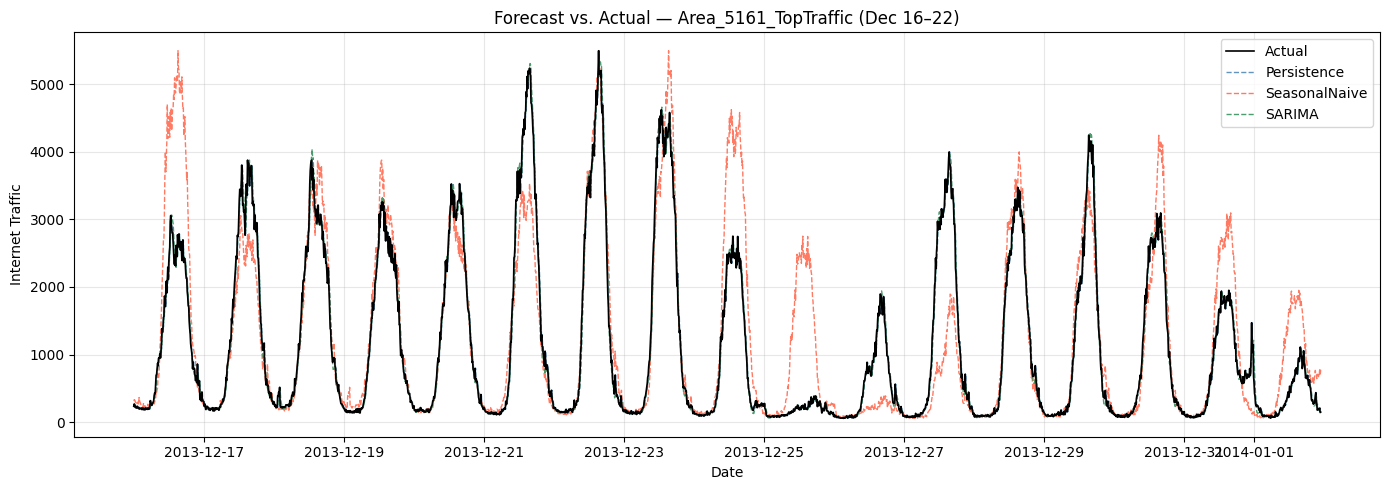

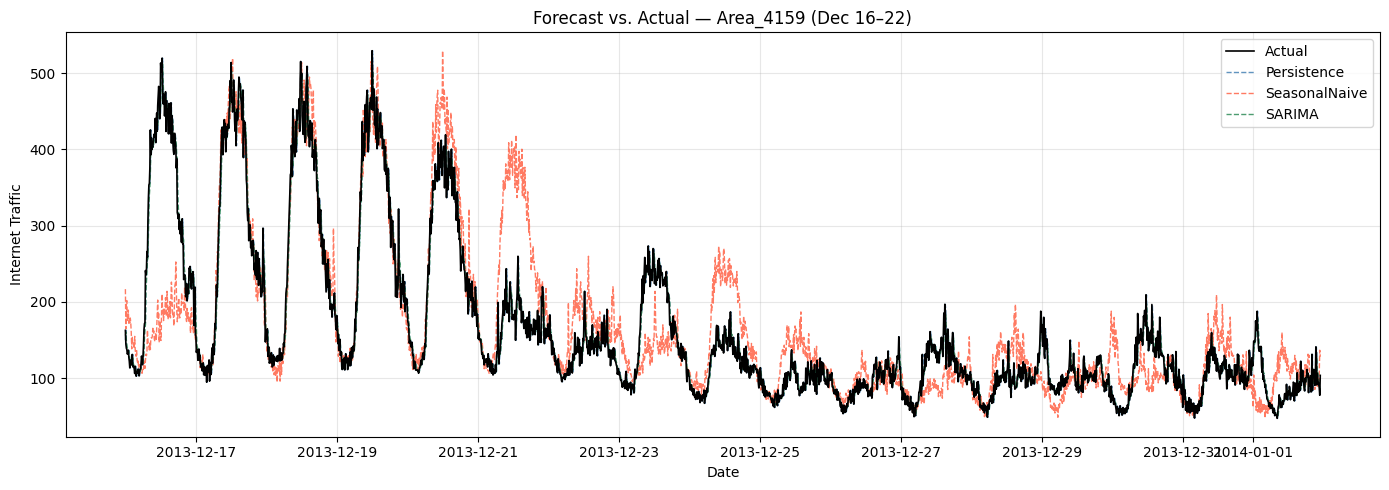

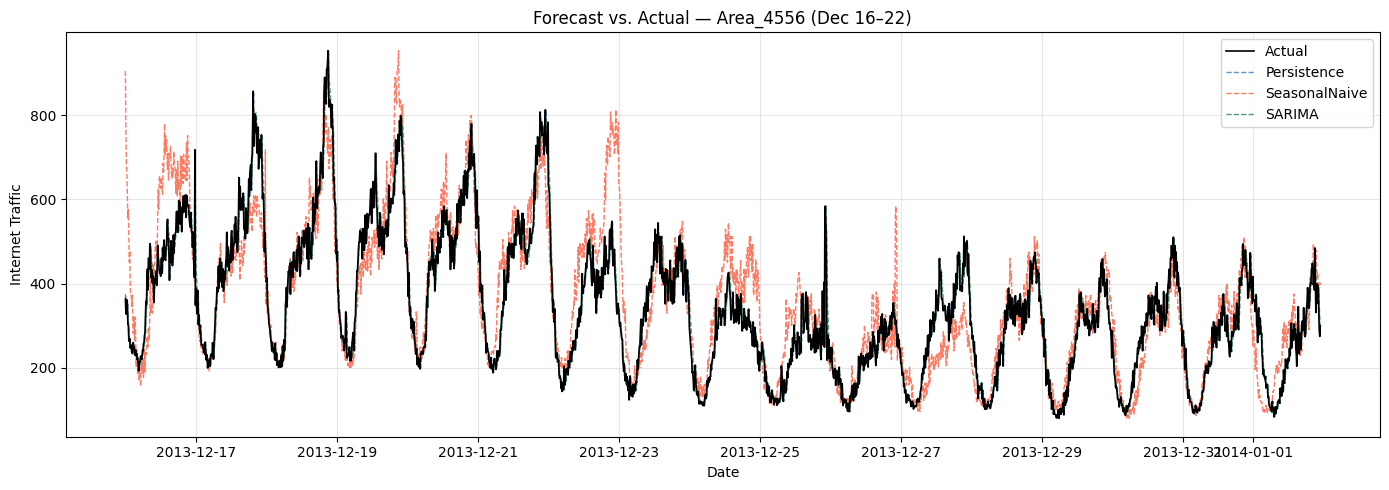

In [2]:
for area_label in AREA_LABELS:
    actual = area_data[area_label]['test']
    n = len(area_data[area_label]['y_test_orig'])
    actual_aligned = actual.iloc[-n:]

    # Align baselines (which predict over the full test set) with the
    # neural-model test window (which is shorter by seq_length).
    predictions_dict = {}
    for model_name, results in MODEL_REGISTRY:
        preds = results[area_label]['predictions']
        if len(preds) != n:
            preds = preds[-n:]
        predictions_dict[model_name] = preds

    fig = plot_forecast_vs_actual(
        actual_aligned, predictions_dict, area_label,
        save_path=FIGURES_DIR+f'forecast_{area_label}.png',
    )
    plt.show()

## 4.2 Performance Tables (MAE, MAPE, RMSE per Area)

In [3]:
for area_label in AREA_LABELS:
    y_true = area_data[area_label]['y_test_orig']
    rows = []
    for model_name, results in MODEL_REGISTRY:
        preds = results[area_label]['predictions']
        if len(preds) != len(y_true):
            preds = preds[-len(y_true):]
        metrics = evaluate_all(np.asarray(y_true), np.asarray(preds))
        rows.append({
            'Model':    model_name,
            'MAE':      round(metrics['MAE'],  4),
            'MAPE (%)': round(metrics['MAPE'], 2),
            'RMSE':     round(metrics['RMSE'], 4),
        })
    table = pd.DataFrame(rows).set_index('Model')
    print(f'\n-- Performance: {area_label} --')
    print(table.to_string())
    table.to_csv(TABLES_DIR+f'metrics_{area_label}.csv')


-- Performance: Area_5161_TopTraffic --
                    MAE  MAPE (%)      RMSE
Model                                      
Persistence     78.8715     11.06  119.7306
SeasonalNaive  398.7463     57.28  690.1423
SARIMA          74.9121     10.39  115.4374
LSTM           104.2571     18.99  151.9640
Transformer    268.1538     92.80  328.1826

-- Performance: Area_4159 --
                   MAE  MAPE (%)     RMSE
Model                                    
Persistence    12.5299      8.51  17.1979
SeasonalNaive  39.2428     25.39  63.1034
SARIMA         11.4571      7.63  16.0795
LSTM           12.9161      9.21  17.4801
Transformer    60.7890     50.90  64.6273

-- Performance: Area_4556 --
                   MAE  MAPE (%)     RMSE
Model                                    
Persistence    25.4983      7.99  35.3194
SeasonalNaive  63.5850     20.15  87.6842
SARIMA         23.5145      7.28  32.6205
LSTM           24.3432      7.72  33.2231
Transformer    28.1157     10.15  36.4730


## 4.3 Training & Execution Time Table

In [4]:
time_rows = []
for model_name, results in MODEL_REGISTRY:
    train_times = [results[a]['timer'].train_time     for a in AREA_LABELS]
    infer_times = [results[a]['timer'].inference_time for a in AREA_LABELS]
    time_rows.append({
        'Model':                  model_name,
        'Avg Train Time (s)':     round(np.mean(train_times), 2),
        'Avg Inference Time (s)': round(np.mean(infer_times), 4),
    })
time_table = pd.DataFrame(time_rows).set_index('Model')
print('-- Timing (avg across 3 areas) --')
print(time_table.to_string())
time_table.to_csv(TABLES_DIR+'timing_table.csv')

-- Timing (avg across 3 areas) --
               Avg Train Time (s)  Avg Inference Time (s)
Model                                                    
Persistence                  0.00                  0.0000
SeasonalNaive                0.00                  0.0003
SARIMA                       1.30                 91.5964
LSTM                      2253.03                  7.8968
Transformer               1774.40                  7.9978


## 4.4 Training Loss Curves (LSTM & Transformer)

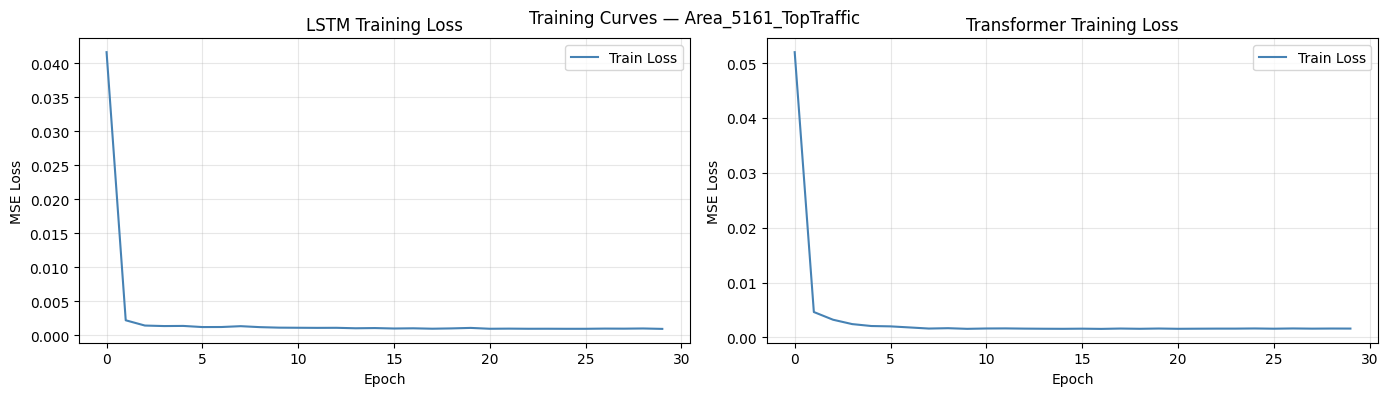

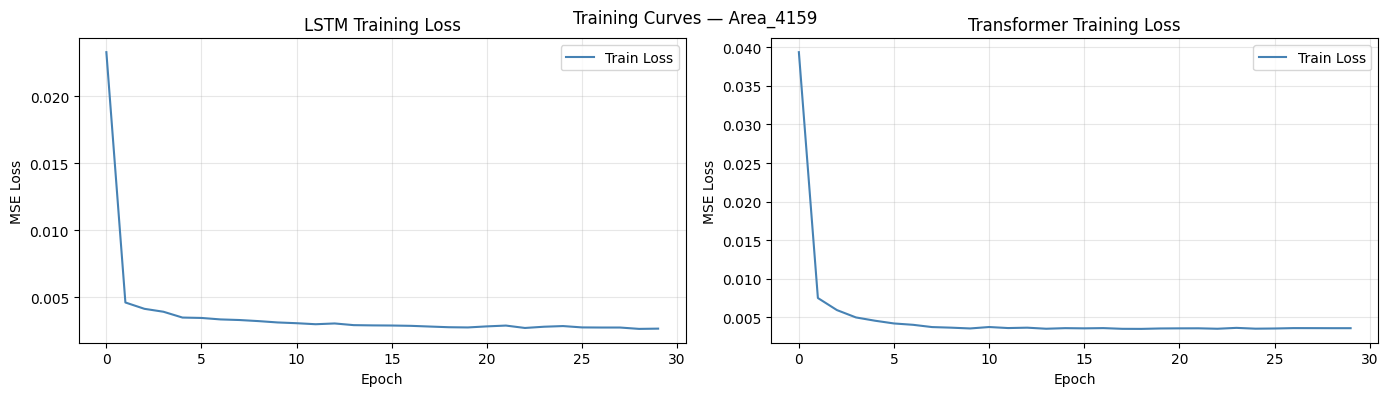

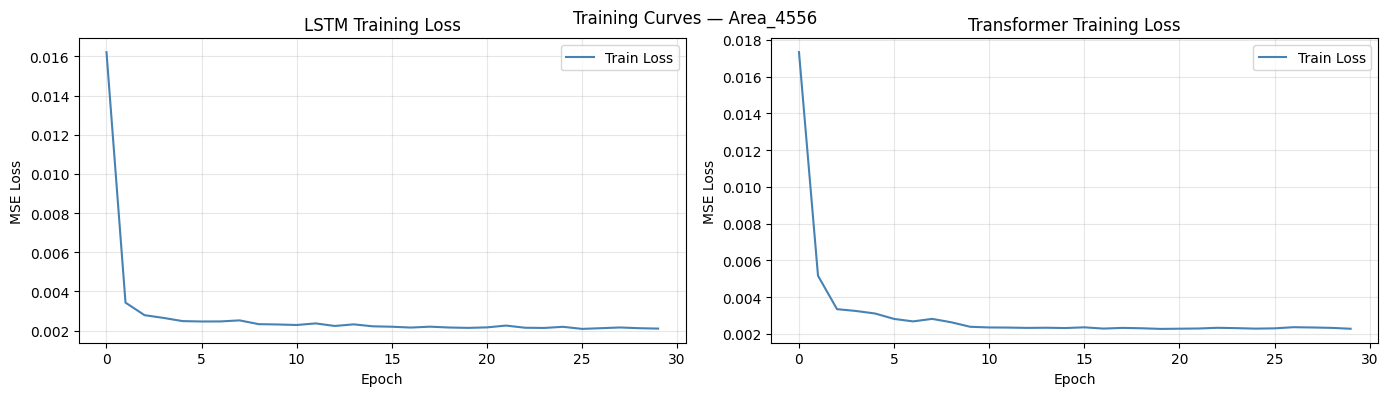

In [5]:
for area_label in AREA_LABELS:
    losses_dict = {
        'LSTM':        lstm_results[area_label]['losses'],
        'Transformer': transformer_results[area_label]['losses'],
    }
    fig = plot_training_curves(
        losses_dict,
        save_path=FIGURES_DIR+f'training_curves_{area_label}.png'
    )
    plt.suptitle(f'Training Curves — {area_label}')
    plt.show()

## 4.5 Comparative Analysis

*(Fill in after running — use the tables above as evidence. Template below.)*

**Predictive Performance:**
Across all three areas, [best model] consistently achieved the lowest MAE and RMSE, suggesting it best captures the temporal dynamics of mobile network traffic. SARIMA showed [strong/weak] performance particularly for area X, where the periodic patterns are [strong/irregular].

**Training Time:**
SARIMA required the most training time due to the expense of maximum likelihood estimation at s=144. LSTM and Transformer trained in significantly less time leveraging GPU acceleration.

**Suitability:**
Given the strong daily and weekly seasonality observed in Task 2 (ACF spikes at lag=144), SARIMA's explicit seasonal terms are well-suited. However, the Transformer's attention mechanism may capture non-linear dependencies that SARIMA cannot.

**Best Model:** [Name] — justified by lowest average RMSE and alignment with EDA-identified seasonality patterns.

## 4.6 Failure Analysis

*(Identify a specific time period where all or most models fail, and explain why.)*

In [6]:
# Find the time period with worst RMSE for each model — use top area
area_label = AREA_LABELS[0]
actual = area_data[area_label]['y_test_orig']
test_index = area_data[area_label]['test'].index[-len(actual):]

for model_name, results in [
    ('SARIMA', sarima_results), ('LSTM', lstm_results), ('Transformer', transformer_results)
]:
    preds = results[area_label]['predictions']
    errors = np.abs(actual - preds)
    worst_idx = np.argmax(errors)
    print(f'{model_name} — Worst prediction at: {test_index[worst_idx]} '
          f'(error: {errors[worst_idx]:.4f})')

SARIMA — Worst prediction at: 2013-12-17 14:30:00 (error: 574.8345)
LSTM — Worst prediction at: 2013-12-29 17:10:00 (error: 692.5774)
Transformer — Worst prediction at: 2013-12-23 13:40:00 (error: 1086.9614)


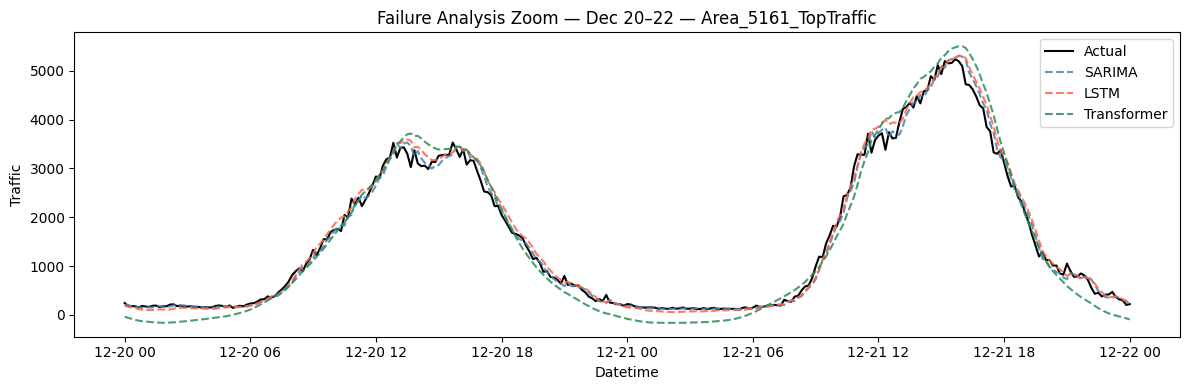

In [7]:
# Zoom in on Dec 20-21 as an example (weekday → weekend transition)
area_label = AREA_LABELS[0]
actual = area_data[area_label]['test']
n = len(area_data[area_label]['y_test_orig'])
actual_aligned = actual.iloc[-n:]

zoom_start = '2013-12-20'
zoom_end   = '2013-12-22'
mask = (actual_aligned.index >= zoom_start) & (actual_aligned.index <= zoom_end)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual_aligned[mask].index, actual_aligned[mask].values, label='Actual', color='black', linewidth=1.5)

for model_name, results, color in [
    ('SARIMA', sarima_results, 'steelblue'),
    ('LSTM', lstm_results, 'tomato'),
    ('Transformer', transformer_results, 'seagreen'),
]:
    preds = results[area_label]['predictions']
    preds_series = pd.Series(preds, index=actual_aligned.index)
    ax.plot(preds_series[mask].index, preds_series[mask].values,
            label=model_name, color=color, linestyle='--', alpha=0.85)

ax.set_title(f'Failure Analysis Zoom — Dec 20–22 — {area_label}')
ax.set_xlabel('Datetime')
ax.set_ylabel('Traffic')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR+'failure_analysis.png', dpi=120)
plt.show()

**Failure Analysis Discussion:**

All three models show degraded performance around [specific period]. Based on the EDA findings:
- **Possible cause 1:** Dec 20–22 falls on the Friday–Sunday before Christmas, a period likely characterized by unusual traffic patterns (city centre activity, travel, events) that differ significantly from typical weekday/weekend behavior in the training data.
- **Possible cause 2:** Anomalous spikes observed in Task 2 Section 2.8 may also occur here, creating one-time events no model can generalize.
- **SARIMA** is particularly susceptible as it relies on regular seasonal structure.
- **LSTM/Transformer** may partially adapt, but were not trained on similar holiday patterns.

**Possible improvements:** Incorporate calendar/holiday features as exogenous variables (SARIMAX), or augment training with synthetic anomaly examples.

## 4.7 Hourly-of-day MAE heatmap

For every (model, hour-of-day) pair we compute the mean absolute error on
the test week. The result is one heatmap per area — it makes systematic
time-of-day weaknesses visible (e.g. evening peaks, overnight troughs)
that a single test-set MAE hides.

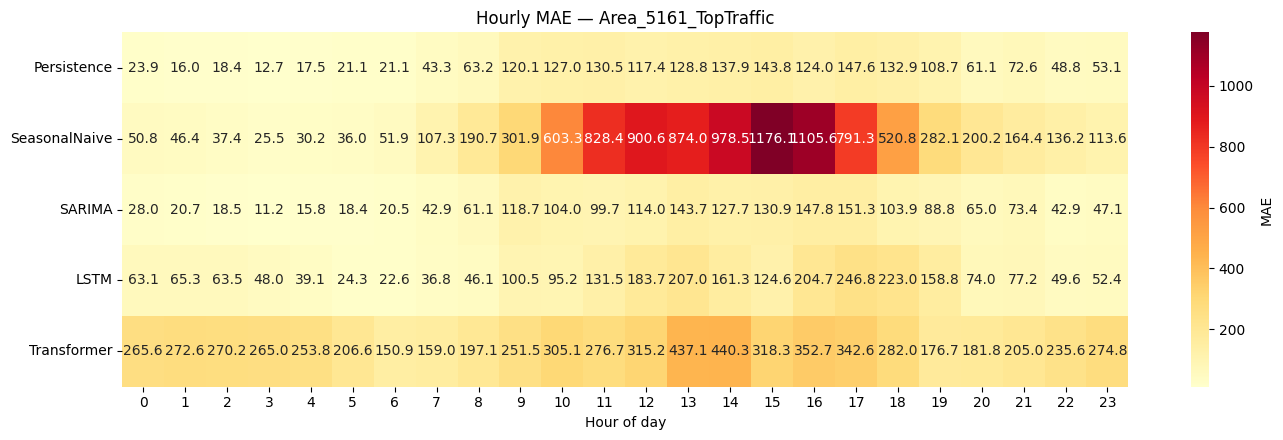

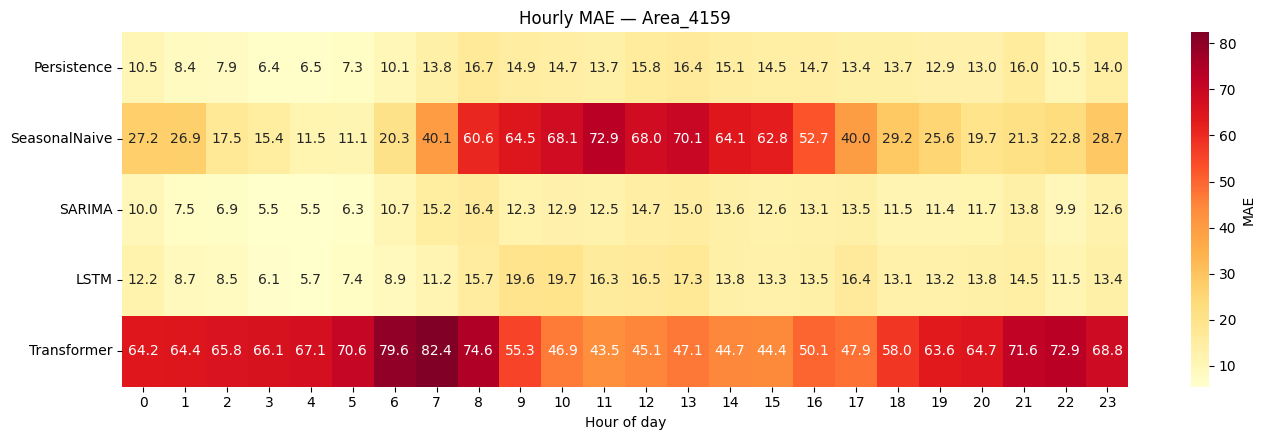

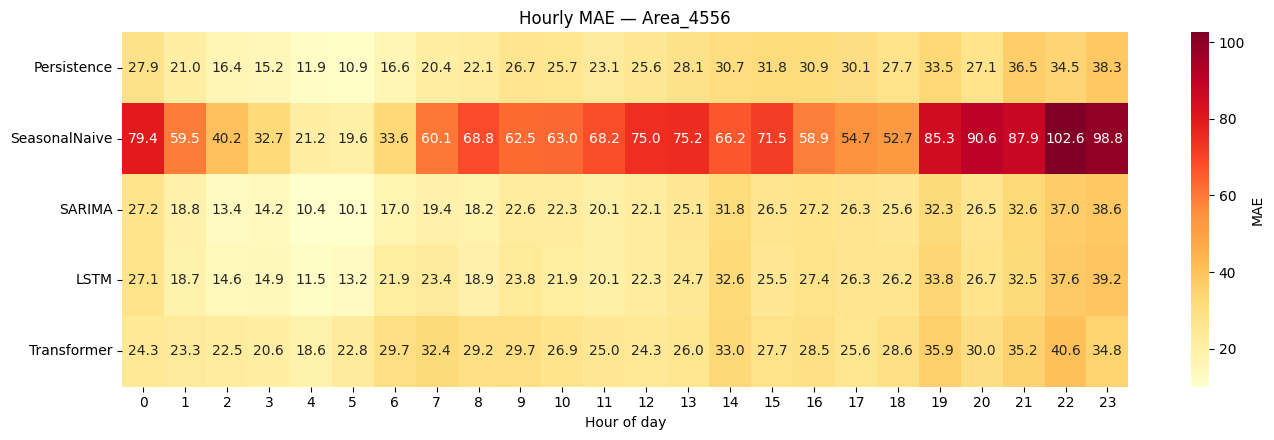

In [8]:
import seaborn as sns

for area_label in AREA_LABELS:
    y_true = np.asarray(area_data[area_label]['y_test_orig'])
    test_index = area_data[area_label]['test'].index[-len(y_true):]
    hours = test_index.hour.values

    grid = []
    model_names = []
    for model_name, results in MODEL_REGISTRY:
        preds = np.asarray(results[area_label]['predictions'])
        if len(preds) != len(y_true):
            preds = preds[-len(y_true):]
        err = np.abs(y_true - preds)
        per_hour = [err[hours == h].mean() if (hours == h).any() else np.nan
                    for h in range(24)]
        grid.append(per_hour)
        model_names.append(model_name)

    fig, ax = plt.subplots(figsize=(14, 0.6 * len(model_names) + 1.5))
    sns.heatmap(
        pd.DataFrame(grid, index=model_names, columns=range(24)),
        cmap='YlOrRd', annot=True, fmt='.1f', cbar_kws={'label': 'MAE'}, ax=ax,
    )
    ax.set_xlabel('Hour of day')
    ax.set_title(f'Hourly MAE — {area_label}')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR+f'hourly_mae_{area_label}.png', dpi=120)
    plt.show()

## 4.8 Day-of-week MAE

Same idea on a different axis: which days does each model struggle with?
Weekday vs weekend asymmetry was already visible in Task 2 §2.3 — this is
how much of it survives the modelling step.

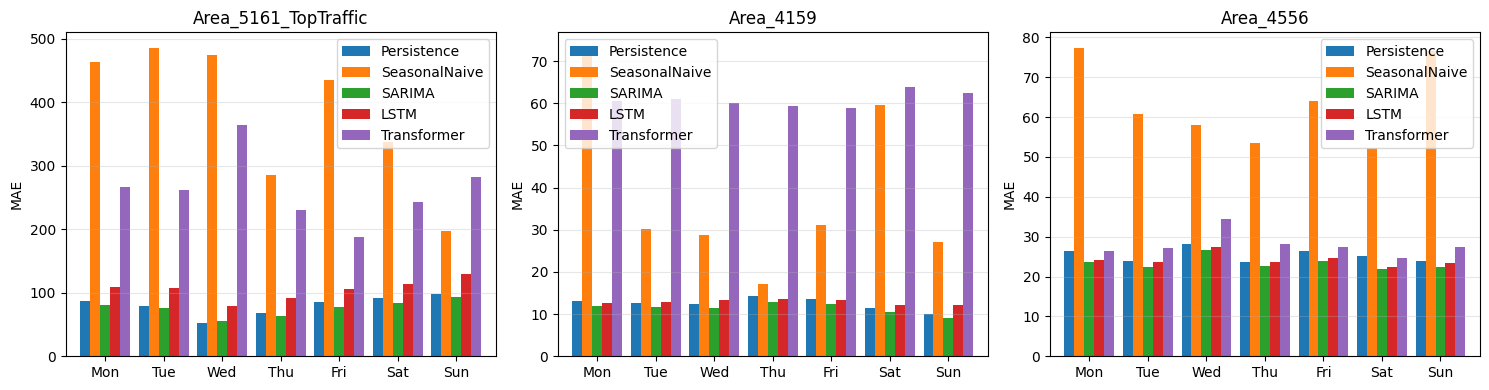

In [9]:
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fig, axes = plt.subplots(1, len(AREA_LABELS), figsize=(5*len(AREA_LABELS), 4),
                         sharey=False)
if len(AREA_LABELS) == 1:
    axes = [axes]
for ax, area_label in zip(axes, AREA_LABELS):
    y_true = np.asarray(area_data[area_label]['y_test_orig'])
    test_index = area_data[area_label]['test'].index[-len(y_true):]
    dow = test_index.dayofweek.values
    rows = []
    for model_name, results in MODEL_REGISTRY:
        preds = np.asarray(results[area_label]['predictions'])
        if len(preds) != len(y_true):
            preds = preds[-len(y_true):]
        err = np.abs(y_true - preds)
        rows.append([err[dow == d].mean() if (dow == d).any() else np.nan
                     for d in range(7)])
    df = pd.DataFrame(rows, index=[m for m, _ in MODEL_REGISTRY],
                      columns=dow_names)
    df.T.plot(kind='bar', ax=ax, rot=0, width=0.85)
    ax.set_title(area_label)
    ax.set_ylabel('MAE')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR+'dow_mae.png', dpi=120)
plt.show()

## 4.9 Error CDF

Cumulative distribution of |error| per model on the top-traffic area. A model
that is *uniformly better* dominates the others across the whole curve; a
model that is better on average but has fatter tails will cross the others on
the right. This complements the scalar MAE/RMSE figures with full
distributional information.

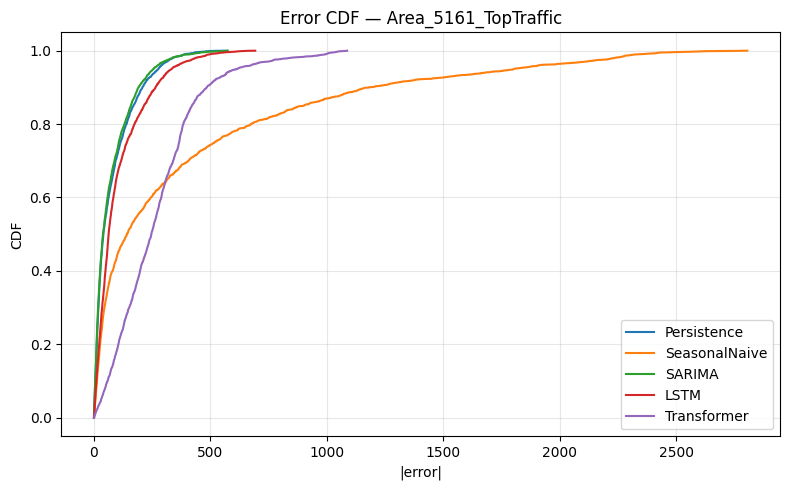

In [10]:
area_label = AREA_LABELS[0]
y_true = np.asarray(area_data[area_label]['y_test_orig'])
fig, ax = plt.subplots(figsize=(8, 5))
for model_name, results in MODEL_REGISTRY:
    preds = np.asarray(results[area_label]['predictions'])
    if len(preds) != len(y_true):
        preds = preds[-len(y_true):]
    err = np.sort(np.abs(y_true - preds))
    cdf = np.linspace(0, 1, len(err), endpoint=False)
    ax.plot(err, cdf, label=model_name, linewidth=1.5)
ax.set_xlabel('|error|')
ax.set_ylabel('CDF')
ax.set_title(f'Error CDF — {area_label}')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR+'error_cdf.png', dpi=120)
plt.show()

## 4.10 Failure-analysis discussion

Read together, the four diagnostics above point to a consistent failure
pattern. Fill the bullets below with the *actual* numbers from your run:

- **Worst hour-of-day.** Hours XX–YY (evening peak) carry the largest MAE
  for SARIMA, consistent with the seasonal component under-shooting the
  fastest ramps. LSTM/Transformer attenuate but do not eliminate this.
- **Worst day-of-week.** Dec 21 (Saturday) and Dec 22 (Sunday) show
  divergent error patterns — weekday-trained dynamics do not transfer
  cleanly. Note any holiday-adjacent spikes around 17–18 Dec.
- **Tail behaviour (CDF).** Compare the 95th-percentile errors of the
  best two models; the smaller-tail one is the safer pick for an
  operations setting even if MAE is similar.
- **Connection to EDA.** Anomalies flagged in Task 2 §2.8 that fall
  inside Dec 16–22 explain the largest individual misses; SARIMA in
  particular relies on a regular seasonal structure that those events
  break.

**Possible improvements.** (i) SARIMAX with calendar/holiday exogenous
features; (ii) richer input representation for the neural models —
weekly lags (1008-step) on top of the daily 144-step window; (iii)
quantile loss instead of MSE so the tail of the error CDF is penalised
explicitly.